# Lecture 5: Memory Without Words: How Neural Networks Remember

**«Память без слов: как нейронные сети запоминают»**


# Section 0: The Memory Enigma — Where Does the Past Live?

```
┌─────────────────────────────────────────────────────────────────────┐
│  Layer 1 — FROZEN WEIGHTS                                           │
│  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  │
│  what the model knows before any conversation begins                │
│  (billions of compressed patterns from training)                    │
└─────────────────────────────────────────────────────────────────────┘
                              ▲ reads from
┌─────────────────────────────────────────────────────────────────────┐
│  Layer 2 — EXTERNAL LATENT MEMORY                                   │
│  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  │
│  what the model writes and reads during an episode                  │
│  (differentiable vectors, addressed by content)                     │
└─────────────────────────────────────────────────────────────────────┘
                              ▲ reads from
┌─────────────────────────────────────────────────────────────────────┐
│  Layer 3 — ATTENTION WINDOW                                         │
│  ████████████████████████████████████████████████████████████████  │
│  what the model is currently reading                                │
│  (tokens in context, full fidelity, strictly bounded)              │
└─────────────────────────────────────────────────────────────────────┘
```

Every language model lives inside a window. It reads the text you give it, produces a response, and then — in a fundamental sense — forgets. The next conversation starts fresh. This is not an engineering oversight; it is a deliberate design choice with deep consequences.

So where does the past live? There are three possible answers, and they are not equivalent.

The first is in the **frozen weights** — the billions of parameters adjusted during training that have not changed since. The model "knows" that Paris is the capital of France not because it looked it up, but because that relationship is encoded, distributed across millions of numbers, in the weights themselves. Permanent, but static.

The second is in the **context window** — the tokens currently being processed. Fully faithful and immediately accessible, but strictly bounded. Tokens that fall outside the window simply cease to exist for the model.

**What about RAG — retrieval from an external database?** It looks like a natural third source. But notice what it actually is: text retrieved by Python code *wrapped around* the model, then pasted into the context window. RAG is an agent-level mechanism, not a model-level one. The model itself never writes to it, reads from it directly, or integrates it into its forward pass. It is more like a human writing notes on paper — useful, but separate from the act of thinking.

Consider the analogy directly: a human can either *write something down* (external, symbolic, retrievable by re-reading) or *remember it inside their brain* (internal, distributed, recalled during thinking itself). Writing text in a notebook is RAG. Remembering inside the brain — latent, diffused with intelligence, recalled during the forward pass of cognition — is what this lecture is about.

Classic transformers, and most production LLMs today, use only the first two innate mechanisms: frozen weights and context attention. Some modern architectures go beyond that — implementing a genuine **third mechanism**: external latent memory. A structure that lives outside the weights but speaks the same mathematical language as the model's internal representations. Not text. Vectors. Floating-point numbers the model can write to, read from, and be *trained to use effectively*.

The question this lecture pursues: what does it mean to store a *vector* rather than a *word*? How does it change the structure of the transformer? And why does that difference matter?


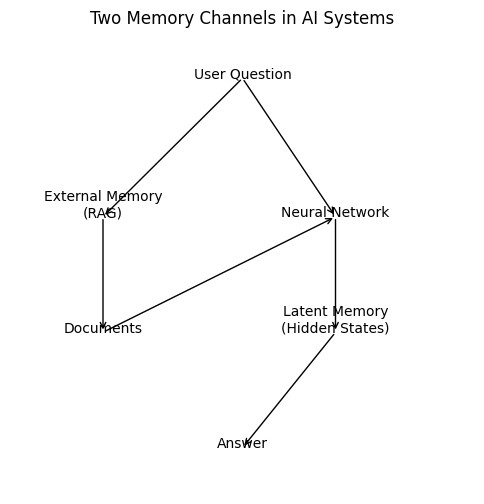

In [3]:
# Tiny diagram: RAG + latent memory pipeline

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.axis("off")

# Positions
pos = {
    "question": (0.5, 0.9),
    "rag": (0.2, 0.6),
    "docs": (0.2, 0.35),
    "model": (0.7, 0.6),
    "latent": (0.7, 0.35),
    "answer": (0.5, 0.1),
}

# Labels
plt.text(*pos["question"], "User Question", ha='center')
plt.text(*pos["rag"], "External Memory\n(RAG)", ha='center')
plt.text(*pos["docs"], "Documents", ha='center')
plt.text(*pos["model"], "Neural Network", ha='center')
plt.text(*pos["latent"], "Latent Memory\n(Hidden States)", ha='center')
plt.text(*pos["answer"], "Answer", ha='center')

# Arrows
def arrow(a, b):
    plt.annotate("", xy=b, xytext=a, arrowprops=dict(arrowstyle="->"))

arrow(pos["question"], pos["rag"])
arrow(pos["rag"], pos["docs"])
arrow(pos["docs"], pos["model"])
arrow(pos["question"], pos["model"])
arrow(pos["model"], pos["latent"])
arrow(pos["latent"], pos["answer"])

plt.title("Two Memory Channels in AI Systems")
plt.show()

# Section 0: The Memory Enigma — Where Does the Past Live?

```
┌─────────────────────────────────────────────────────────────────────┐
│  Layer 1 — FROZEN WEIGHTS                                           │
│  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  │
│  what the model knows before any conversation begins                │
│  (billions of compressed patterns from training)                    │
└─────────────────────────────────────────────────────────────────────┘
                              ▲ reads from
┌─────────────────────────────────────────────────────────────────────┐
│  Layer 2 — EXTERNAL LATENT MEMORY                                   │
│  ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒  │
│  what the model writes and reads during an episode                  │
│  (differentiable vectors, addressed by content)                     │
└─────────────────────────────────────────────────────────────────────┘
                              ▲ reads from
┌─────────────────────────────────────────────────────────────────────┐
│  Layer 3 — ATTENTION WINDOW                                         │
│  ████████████████████████████████████████████████████████████████  │
│  what the model is currently reading                                │
│  (tokens in context, full fidelity, strictly bounded)              │
└─────────────────────────────────────────────────────────────────────┘
```

Every LLM lives inside a window. Tokens that fall outside the window are gone — not compressed, not summarized, simply absent from the computation. This is the defining constraint of the transformer architecture, and it is not a bug waiting to be fixed. It is a fundamental tradeoff between expressiveness and computational cost.

RAG (Retrieval-Augmented Generation) is the pragmatic answer: store text outside the model, retrieve the relevant chunks, paste them into the context window. It works. But it stores *text* — discrete tokens that must be retrieved, re-parsed, and re-embedded on every call. The memory lives outside the model's representational substrate.

The Neural Turing Machine takes a different path. Instead of storing text, it stores *vectors* — the same kind of floating-point representations that flow through the model's internal layers. The memory is outside the weights, yes, but it speaks the same mathematical language as the reasoning process. Reading from it is differentiable. Writing to it is differentiable. The controller can be trained end-to-end to learn *how* to use memory, not just *what* to retrieve.

Why does that feel different? This lecture answers that question precisely. We will build NTM memory from scratch, connect it to the attention mechanism you already know, and then trace how this idea evolved into Memorizing Transformers, Titans, and the state-space models like Mamba. By the end, you will have a principled map of where the past lives — and what it costs to keep it there.

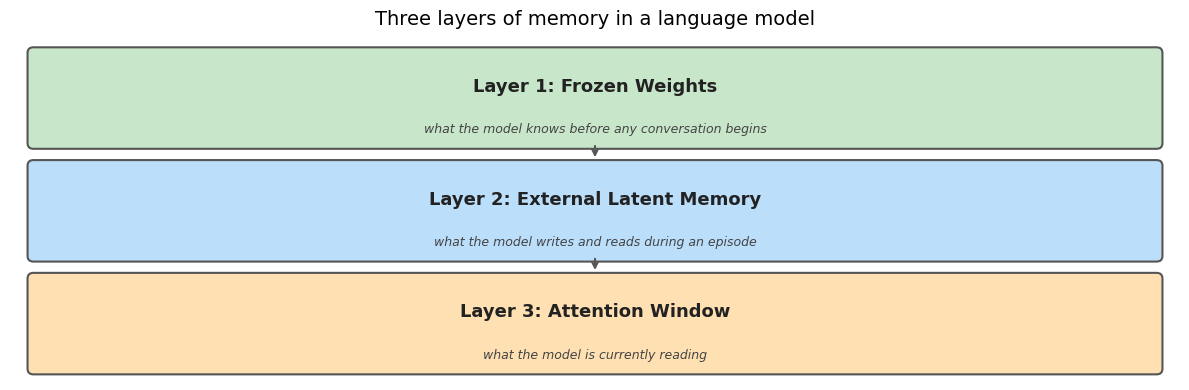

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- define the three layers as (label, description, color) ---
layers: list[tuple[str, str, str]] = [
    ("Layer 1: Frozen Weights",
     "what the model knows before any conversation begins",
     "#c8e6c9"),
    ("Layer 2: External Latent Memory",
     "what the model writes and reads during an episode",
     "#bbdefb"),
    ("Layer 3: Attention Window",
     "what the model is currently reading",
     "#ffe0b2"),
]

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(layers))
ax.axis("off")

# --- draw each layer as a horizontal bar with label and description ---
for i, (title, description, color) in enumerate(layers):
    y: float = len(layers) - 1 - i
    rect = mpatches.FancyBboxPatch(
        (0.2, y + 0.1), 9.6, 0.8,
        boxstyle="round,pad=0.05",
        facecolor=color, edgecolor="#555", linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(5.0, y + 0.6, title, ha="center", va="center",
            fontsize=13, fontweight="bold", color="#222")
    ax.text(5.0, y + 0.22, description, ha="center", va="center",
            fontsize=9, color="#444", style="italic")

# --- draw arrows between layers ---
for i in range(len(layers) - 1):
    y_arrow: float = len(layers) - 1 - i
    ax.annotate(
        "", xy=(5, y_arrow + 0.1), xytext=(5, y_arrow - 0.05),
        arrowprops=dict(arrowstyle="<-", color="#555", lw=1.5)
    )

ax.set_title(
    "Three layers of memory in a language model",
    fontsize=14, pad=12
)
plt.tight_layout()
plt.show()

# Section 1 — Attention as Associative Memory

**Associative memory** is a memory system where: you retrieve stored information not by an address, but by similarity to a cue.

This is the opposite of RAM, where you say “give me slot #42.”

In associative memory, you say: “Here is a pattern. Give me one or few of the stored patterns that most resembles it.”

This is how humans recall:
- You hear the first notes of a song → the whole melody comes back
- You see a fragment of a face → you remember the person
- You smell something → you recall a childhood scene
The cue associates to the stored memory.

**Let's build a basic pattern association primitive

>> A single attention step is a basic pattern‑association primitive: a query representation acts as a retrieval cue, selecting the stored representation whose key is most similar. This is precisely the operation performed by modern Hopfield networks and other associative memory systems.

## 1a. Computing Attention

1. Memory is a set of facts represented as **values**: meanings / concepts / features / facts / embeddings / representations
2. Each of the values is characterized by a **key**: a characteristic property of the value that represents its proposition
3. To use the memory we should use **queries** which we will associate with **keys** -> **attenton** of the query to each of facts

| Component | Role |
|-----------|------|
| Value     | Product to buy and use |
| Key       | Advertisement of the product |
| Query     | Consumer's need in a product |
| Attention | A probability that this product suits this user's need |

Memory usage route:

```
Shopping:
  -> Query (shopping needs)
  -> Map to product keys (need-to-advertisement) 
  -> selected keys (shopping list) 
  -> products (shopping cart)
```


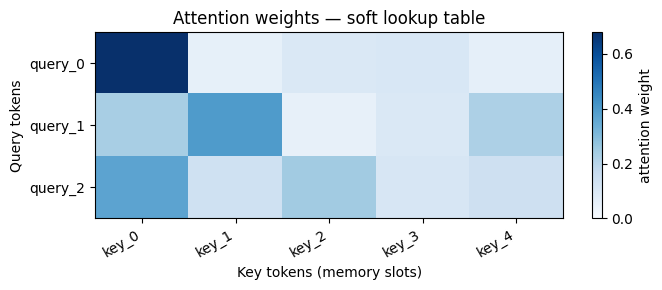

Query 'query_1' retrieves mostly from key 'key_1' (weight=0.396) — this is a soft lookup


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42) # Make the world deterministic

# --- dimensions and synthetic query / key / value tensors ---
n_queries: int = 3  # Number of shopping needs
n_keys: int = 5     # Number of value providers (1 key per value)
d_k: int = 8        # Dimensionality of representations

Q: torch.Tensor = torch.randn(n_queries, d_k) # What to ask every from every provider (shopping)
K: torch.Tensor = torch.randn(n_keys, d_k)    # What this provider can offer to every other token (advertisement)
V: torch.Tensor = torch.randn(n_keys, d_k)    # What this provider will produce when selected (product)
# Values are: features, meanings, concepts, attractors, facts, embeddings, memory slots -> representations

# Define shopping requests and provider offerings
query_labels: list[str] = [f"query_{i}" for i in range(n_queries)]
key_labels: list[str] = [f"key_{i}" for i in range(n_keys)]

# --- scaled dot-product attention scores ---
# Each query vector (Q) is compared to every key vector (K) using a dot product, 
# producing a matrix of similarity scores. 
# The division by \sqrt{d_k} prevents the scores from blowing up as dimensionality grows.
# This is scaled Dot-Product Attention trick from Vaswani et al. (2017).
scores: torch.Tensor = Q @ K.T / (d_k ** 0.5)       # shape: (n_queries, n_keys)

# Turns raw similarity scores into a probability distribution
# All weights are positive. They sum to 1. Higher similarity → higher weight.
# For each query, softmax decides how much attention to pay to each key.
weights: torch.Tensor = F.softmax(scores, dim=-1)   # shape: (n_queries, n_keys) Normalized probabilities

# --- visualize attention weights as a heatmap ---
fig, ax = plt.subplots(figsize=(7, 3))
im = ax.imshow( # Defined how each attention weight becomes a color.
    weights.detach().numpy(), cmap="Blues", aspect="auto", 
    vmin=0, vmax=weights.max().item()
)
ax.set_xticks(range(n_keys))
ax.set_xticklabels(key_labels, rotation=30, ha="right")
ax.set_yticks(range(n_queries))
ax.set_yticklabels(query_labels)
ax.set_xlabel("Key tokens (memory slots)")
ax.set_ylabel("Query tokens")
ax.set_title("Attention weights — soft lookup table")
plt.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout()
plt.show()

# --- identify the strongest retrieved key for query_1 ---
top_key_idx: int = int(weights[1].argmax().item())
print(f"Query 'query_1' retrieves mostly from key '{key_labels[top_key_idx]}' "
      f"(weight={weights[1, top_key_idx]:.3f}) — this is a soft lookup")

<details>
<summary>Modern hopfield networks — attention is energy minimization</summary>

In 2020, Ramsauer et al. showed that the scaled dot-product attention update rule is mathematically equivalent to one step of energy minimization in a *modern Hopfield network* — a generalization of the classical 1982 Hopfield associative memory. The stored patterns are the rows of the value matrix V, and the retrieval cue is the query Q. The softmax ensures the system converges toward the stored pattern most similar to the cue, rather than getting stuck in spurious attractors.

The key insight is that attention was already doing associative memory retrieval — the transformer community just did not name it that way. When you run a softmax over dot products between a query and a set of keys, you are performing one iteration of a content-addressable memory lookup. This reframing is not merely academic: it explains *why* attention generalizes so well, and it directly motivates the NTM architecture we build in Section 2 — which simply makes the memory matrix a trainable external store rather than a fixed set of context tokens.

</details>

<details>
<summary>Hopfield networks and QKVs - in depth</summary>

Let’s go deep — *mathematically deep* — into why **scaled dot‑product attention is literally one update step of a modern Hopfield network**, and why this reframing is so powerful for your ANIMA architecture.

I’ll unpack this in layers:

1. **What a modern Hopfield network is**  
2. **Its energy function and update rule**  
3. **How attention exactly matches that update rule**  
4. **Why softmax is the key to stability and avoiding spurious attractors**  
5. **Why this matters for Transformers and for your NTM‑style memory**

---

# 1. 🧠 Modern Hopfield networks (2020)

Classical Hopfield networks (1982) store patterns \( x_i \in \mathbb{R}^d \) as attractors of a dynamical system.  
Modern Hopfield networks (Ramsauer et al., 2020) generalize this by:

- allowing **continuous states**
- allowing **exponentially many stored patterns**
- using a **log-sum-exp energy function** instead of a quadratic one

The stored patterns are vectors \( \xi_1, \dots, \xi_N \in \mathbb{R}^d \).

The system has a state vector \( q \in \mathbb{R}^d \) (the “query”).

---

# 2. ⚡ The modern Hopfield energy function

The energy is:

\[
E(q) = -\log \sum_{i=1}^N \exp(\beta \, \xi_i^\top q)
\]

This is a **log-sum-exp** over similarities between the state \(q\) and stored patterns \( \xi_i \).

- \( \beta \) is an inverse temperature (controls sharpness)
- Lower energy means “closer to a stored pattern”

The network updates its state by **gradient descent** on this energy:

\[
q_{\text{new}} = \frac{\sum_i \xi_i \exp(\beta \xi_i^\top q)}{\sum_j \exp(\beta \xi_j^\top q)}
\]

This is the key equation.

Look at it carefully:

\[
q_{\text{new}} = \sum_i \underbrace{\text{softmax}_i(\beta \xi_i^\top q)}_{\text{attention weight}} \, \xi_i
\]

This is **exactly** the attention update rule.

---

# 3. 🎯 Attention = one Hopfield update step

Transformer attention computes:

\[
\text{weights}_i = \text{softmax}_i\left(\frac{Q K^\top}{\sqrt{d_k}}\right)
\]

\[
\text{output} = \sum_i \text{weights}_i \, V_i
\]

Now identify the pieces:

| Hopfield network | Transformer attention |
|------------------|-----------------------|
| stored patterns \( \xi_i \) | value vectors \( V_i \) |
| similarity \( \xi_i^\top q \) | dot product \( K_i^\top Q \) |
| inverse temperature \( \beta \) | scaling \( 1/\sqrt{d_k} \) |
| softmax over patterns | softmax over keys |
| updated state \( q_{\text{new}} \) | attention output |

So attention is:

\[
\text{output} = \sum_i \text{softmax}_i(K_i^\top Q) \, V_i
\]

which is **identical** to:

\[
q_{\text{new}} = \sum_i \text{softmax}_i(\xi_i^\top q) \, \xi_i
\]

Thus:

> **Scaled dot‑product attention is a single iteration of a modern Hopfield associative memory retrieving the pattern closest to the query.**

This is not an analogy — it is a literal mathematical equivalence.

---

# 4. 🔥 Why softmax matters (no spurious attractors)

Classical Hopfield networks have:

- quadratic energy
- many spurious attractors
- limited capacity (~0.14d patterns)

Modern Hopfield networks use:

\[
E(q) = -\log \sum_i \exp(\beta \xi_i^\top q)
\]

This energy has:

- **no spurious attractors**
- **exponential capacity** in \(d\)
- **guaranteed convergence** to a stored pattern

Softmax is the gradient of log-sum-exp:

\[
\nabla_q E(q) = -\sum_i \text{softmax}_i(\beta \xi_i^\top q) \, \xi_i
\]

So the softmax is not a heuristic — it is the **mathematically correct update rule** for a stable associative memory.

This explains why attention is so robust and generalizes so well.

---

# 5. 🧩 Why this matters for your NTM/ANIMA architecture

You’re building a system where:

- memory is **external**
- memory slots are **trainable**
- retrieval is **content-based**
- reasoning is **SSM-driven**
- the transformer is a **decoder of latent plans**

The Hopfield reinterpretation gives you:

### **(1) A principled energy-based view of memory retrieval**
Your NTM memory lookup is not just “attention-like” — it *is* a Hopfield update.

### **(2) A guarantee of stability**
Softmax-based retrieval avoids catastrophic attractors.

### **(3) A justification for using dot-product similarity**
It is the natural energy gradient for associative memory.

### **(4) A path to multi-step retrieval**
Multiple attention layers = multiple Hopfield iterations = deeper convergence.

### **(5) A reason to make memory persistent**
Transformers treat context tokens as stored patterns.  
Your NTM simply makes those patterns **explicit and trainable**, not ephemeral.

---

# 🧠 The big conceptual punchline

> **Attention is not a routing mechanism. It is a differentiable associative memory performing energy minimization.**

Transformers accidentally reinvented Hopfield networks — and the 2020 paper simply revealed the equivalence.

Your ANIMA architecture is doing the *intentional* version of this:  
a persistent, trainable, content-addressable memory with explicit control.

---

If you want, I can go even deeper:

- derive the equivalence step-by-step  
- show how multi-head attention = multiple Hopfield subspaces  
- show how cross-attention = heteroassociative memory  
- show how SSMs can act as the “state dynamics” between Hopfield updates  

Which direction do you want to explore next?

</details>

## 1b — What Does a Value Vector Actually Represent?

Before we write vectors into NTM memory, we should ask a harder question: *what is a vector, and what does it encode?*

A latent vector is a coordinate in a high-dimensional space. But which space depends on several interlocking choices:

**What produced it.**
A token embedding lives close to lexical meaning — the word “bank” has one embedding regardless of whether it means a riverbank or a financial institution. One layer deeper, the vector has been touched by attention: neighboring tokens have contributed to its representation. By layer 12 in a large model, “bank” after “the river” and “bank” after “wire transfer” live in completely different regions of the space.

**When in the sequence it was produced.**
The same word at position 3 (no history yet) produces a different vector than at position 300 (full context already processed). Position is not just an address — it changes the representation.

**How it was pooled.**
A single token vector captures one moment. A mean-pooled span captures a summary. The last-token hidden state of an autoregressive model often acts as a compressed summary of everything before it.

When NTM writes a vector into a memory slot, it writes *one specific point in one specific space* — shaped by all of the above. The slot does not contain “the word Paris.” It contains whatever internal representation the controller chose to write at that moment in that context.

The visualization below makes this concrete: the same token extracted at three different transformer depths. The vectors look different — because they *are* different things.


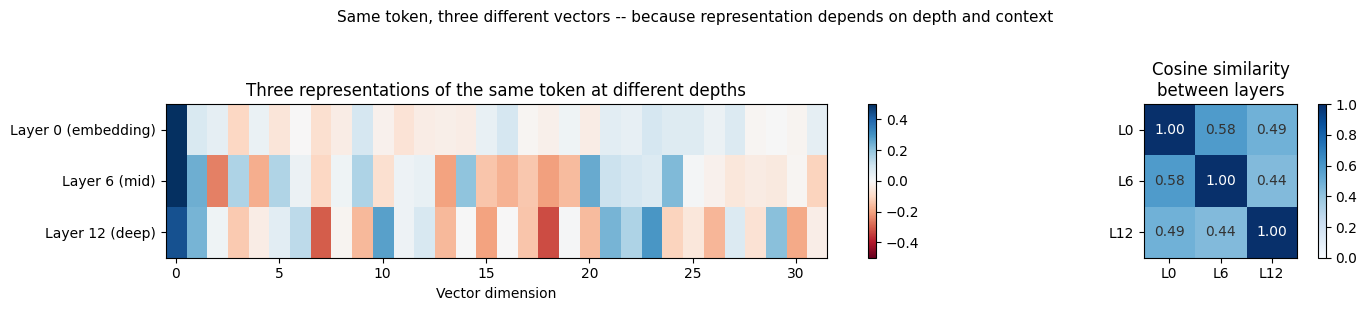

Cosine similarity between layer representations:
  L0 <-> L6: 0.582
  L0 <-> L12: 0.487
  L6 <-> L12: 0.443

The same token is a different vector at each layer.
NTM writes one of these -- but which one? That choice determines what 'memory of X' means.


In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

# synthetic vectors constructed to reflect what layer-probing studies find:
# early layers stay close to the token embedding; later layers rotate substantially.

D: int = 32

# layer 0: raw token embedding -- strong single-dimension lexical signal
layer0_vec: torch.Tensor = torch.zeros(D)
layer0_vec[0] = 1.0
layer0_vec = layer0_vec + torch.randn(D) * 0.05

# layer 6: neighbors have started reshaping the representation via attention
rotation6: torch.Tensor = torch.randn(D, D) * 0.15
layer6_vec: torch.Tensor = F.normalize(layer0_vec + rotation6 @ layer0_vec, dim=0)

# layer 12: fully contextualized; original lexical signal substantially mixed in
rotation12: torch.Tensor = torch.randn(D, D) * 0.4
layer12_vec: torch.Tensor = F.normalize(layer0_vec + rotation12 @ layer6_vec, dim=0)

# stack into matrix: 3 rows (layers) x D columns (dimensions)
layer_matrix: np.ndarray = torch.stack(
    [layer0_vec, layer6_vec, layer12_vec]
).detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 3),
                         gridspec_kw={"width_ratios": [2, 1]})

# left: heatmap of the three representations
im = axes[0].imshow(layer_matrix, cmap="RdBu", vmin=-0.5, vmax=0.5, aspect="auto")
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["Layer 0 (embedding)", "Layer 6 (mid)", "Layer 12 (deep)"])
axes[0].set_xlabel("Vector dimension")
axes[0].set_title("Three representations of the same token at different depths")
plt.colorbar(im, ax=axes[0])

# right: pairwise cosine similarities between the three layer vectors
vecs: list[torch.Tensor] = [layer0_vec, layer6_vec, layer12_vec]
layer_labels: list[str] = ["L0", "L6", "L12"]
sim_matrix: np.ndarray = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        sim_matrix[i, j] = float(
            F.cosine_similarity(vecs[i].unsqueeze(0), vecs[j].unsqueeze(0)).item()
        )

im2 = axes[1].imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(layer_labels)
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(layer_labels)
axes[1].set_title("Cosine similarity\nbetween layers")
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{sim_matrix[i,j]:.2f}",
                     ha="center", va="center", fontsize=10,
                     color="white" if sim_matrix[i, j] > 0.6 else "#333")
plt.colorbar(im2, ax=axes[1])

plt.suptitle(
    "Same token, three different vectors"
    " -- because representation depends on depth and context",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

print("Cosine similarity between layer representations:")
for i, li in enumerate(layer_labels):
    for j, lj in enumerate(layer_labels):
        if j > i:
            print(f"  {li} <-> {lj}: {sim_matrix[i, j]:.3f}")
print()
print("The same token is a different vector at each layer.")
print("NTM writes one of these -- but which one? That choice determines what 'memory of X' means.")


<details>
<summary>the situated representation problem — what it means for memory design</summary>

This is not a technical curiosity — it is a design choice that every memory architecture must answer, explicitly or implicitly.

NTM leaves the choice to the controller: whichever vector the controller produces as its query or add signal is what gets written. The controller learns, from training, which representation is most useful to store. In practice this tends to be something like the hidden state after processing a token — already contextualized by self-attention, but before any output projection.

Memorizing Transformers make a more constrained choice: what gets cached are the K and V projections of each token at a specific layer. These are layer-specific learned linear transformations of the attention input. The geometry of the cached space is the geometry of that layer’s key-value space — which is what makes retrieval by dot-product coherent.

Titans writes into a small MLP whose weights are the memory, so the vector question does not apply in the same way. What gets encoded is implicitly whatever the MLP’s weights, after a gradient step, represent. Less interpretable, but potentially more expressive.

The practical upshot: when you hear “the model stored X in memory,” always ask — at which layer, in which projection, at which position in the sequence? The answer changes what “X” actually is.

</details>


# Section 2 — NTM: Read and Write from Scratch


But attention can only **read** from the tokens already in the context window. What if we could also **write** — update this memory during inference, outside the context window entirely?

We build the core NTM memory module piece by piece: matrix, addressing, read, write.

## 2a — The Memory Matrix

We build a memory matrix: N slots, each holding a latent vector. Think of it as a small RAM made of floating-point vectors.

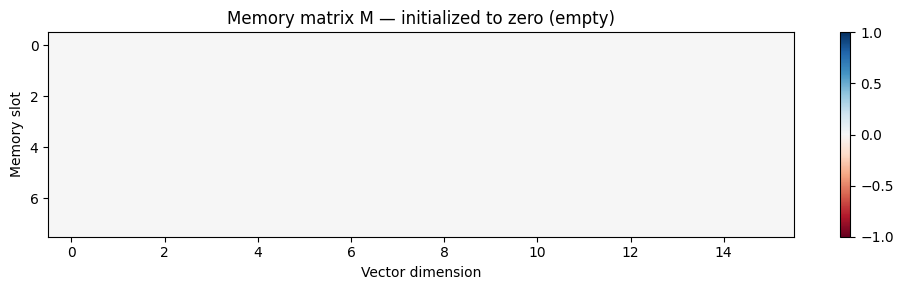

In [7]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

N_SLOTS: int = 8       # number of memory slots
VEC_DIM: int = 16      # dimensionality of each slot

# initialize memory to near-zero (empty memory)
memory: torch.Tensor = torch.zeros(N_SLOTS, VEC_DIM)

# visualize the empty memory matrix
fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(memory.numpy(), cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
ax.set_xlabel("Vector dimension")
ax.set_ylabel("Memory slot")
ax.set_title("Memory matrix M — initialized to zero (empty)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

<details>
<summary>why latent vectors, not tokens</summary>

A Python dictionary stores strings. A database stores rows. The NTM stores *vectors* — the same floating-point tensors that flow through every layer of the network. This choice has one critical consequence: the memory is differentiable.

During training, gradients flow backward through the read and write operations and into the controller that decided *which* slot to address and *what* to write. This means the model can learn, from examples, how to use memory effectively — which slots to use for which kinds of information, when to overwrite, when to preserve. You do not hand-engineer a memory strategy; you train it.

Storing tokens instead of vectors would break this: the argmax operation that selects a token is not differentiable. This is precisely why latent-space memory and text-based RAG feel fundamentally different. RAG retrieves for you; NTM learns to retrieve.

</details>

## 2b — Content-Based Addressing

To read or write, we first ask: which slot is most similar to my query? The answer is a soft probability distribution over all slots — not a hard index.

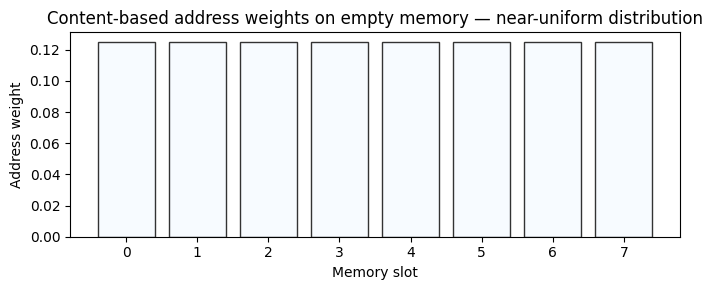

Weights sum to: 1.0000  (should be 1.0)
Min: 0.1250  Max: 0.1250
Empty memory → all slots look equally similar → uniform distribution


In [8]:
def content_address(query: torch.Tensor, memory: torch.Tensor) -> torch.Tensor:
    # cosine similarity between query and each memory slot
    sim: torch.Tensor = F.cosine_similarity(query.unsqueeze(0), memory, dim=1)
    # softmax converts similarities to a probability distribution over slots
    weights: torch.Tensor = F.softmax(sim, dim=0)
    return weights


# demo: random query against empty memory → uniform weights
torch.manual_seed(7)
test_query: torch.Tensor = torch.randn(VEC_DIM)
addr_weights: torch.Tensor = content_address(test_query, memory)

# visualize address weights as a bar chart
fig, ax = plt.subplots(figsize=(7, 3))
colors: np.ndarray = plt.cm.Blues(
    (addr_weights.detach().numpy() - addr_weights.min().item()) /
    (addr_weights.max().item() - addr_weights.min().item() + 1e-9)
)
ax.bar(range(N_SLOTS), addr_weights.detach().numpy(), color=colors, edgecolor="#333")
ax.set_xlabel("Memory slot")
ax.set_ylabel("Address weight")
ax.set_title("Content-based address weights on empty memory — near-uniform distribution")
ax.set_xticks(range(N_SLOTS))
plt.tight_layout()
plt.show()

print(f"Weights sum to: {addr_weights.sum().item():.4f}  (should be 1.0)")
print(f"Min: {addr_weights.min().item():.4f}  Max: {addr_weights.max().item():.4f}")
print("Empty memory → all slots look equally similar → uniform distribution")

<details>
<summary>why softmax and not argmax</summary>

The tempting implementation is: find the slot with the highest cosine similarity and address only that one. This is argmax — and it is not differentiable. The gradient of argmax with respect to its input is zero almost everywhere and undefined at the maximum. No gradient means the controller cannot learn *which* slot to use for *what* purpose.

Softmax is the differentiable relaxation. It produces a probability distribution that is *almost* a one-hot vector when one similarity is much larger than the others, but the gradient flows smoothly back to every similarity score. During training, the model learns to produce queries that are very similar to the keys of the correct slot — making the softmax increasingly sharp and the addressing increasingly precise.

This is the core trick that makes NTM trainable end-to-end: replace every discrete selection operation with a soft, weighted combination. Read becomes a weighted sum. Write becomes a weighted update. The entire system is one smooth function, differentiable from output to input.

</details>

## 2c — Memory Read

Reading from memory: take the weighted sum of all slots, where the weights come from addressing.

In [9]:
def memory_read(weights: torch.Tensor, memory: torch.Tensor) -> torch.Tensor:
    # weighted combination of all memory slots
    retrieved: torch.Tensor = weights @ memory   # shape: (VEC_DIM,)
    return retrieved


# quick sanity check on empty memory
retrieved_vec: torch.Tensor = memory_read(addr_weights, memory)
print(f"Read from empty memory → norm of retrieved vector: {retrieved_vec.norm().item():.4f}")
print("(Should be ~0: nothing stored yet)")

Read from empty memory → norm of retrieved vector: 0.0000
(Should be ~0: nothing stored yet)


## 2d — Memory Write

Writing to memory uses two vectors: an **erase** vector (what to forget) and an **add** vector (what to write). Both are applied proportionally to the address weights.

In [10]:
def memory_write(
    memory: torch.Tensor,
    weights: torch.Tensor,
    erase: torch.Tensor,
    add: torch.Tensor
) -> torch.Tensor:
    # erase: selectively reduce content in addressed slots
    # weights.unsqueeze(1) broadcasts over vector dimension
    memory_erased: torch.Tensor = memory * (1 - weights.unsqueeze(1) * erase.unsqueeze(0))
    # add: write new content into addressed slots
    memory_written: torch.Tensor = memory_erased + weights.unsqueeze(1) * add.unsqueeze(0)
    return memory_written

<details>
<summary>the erase-then-add mechanism</summary>

Why not simply overwrite the slot? Pure overwrite (assigning `memory[slot] = add`) would destroy all previous content in that slot, even dimensions that were storing unrelated useful information. Memory slots are vectors of many dimensions, and the controller may only want to update a subset of those dimensions.

The erase vector solves this. Each element of the erase vector is a number in [0, 1] (produced by a sigmoid), controlling how much of each dimension to clear before writing. An erase element of 1 fully clears that dimension in the addressed slots. An element of 0 leaves it intact. The add vector then writes new content only into the cleared dimensions.

This gives the controller fine-grained control: it can update one dimension of a slot while preserving others. It is the difference between `dict[key] = new_value` and `dict[key].update({specific_field: new_value})`. The latter is strictly more expressive — and that expressiveness is what makes NTM capable of complex algorithmic tasks like sorting and copying.

</details>

## 2e — Demo: Write 5 Facts, Then Query

Now the full demo. We write 5 synthetic 'facts' into memory — each fact is a (key, value) pair encoded as latent vectors. Then we query with exact keys, noisy keys, and an orthogonal key.

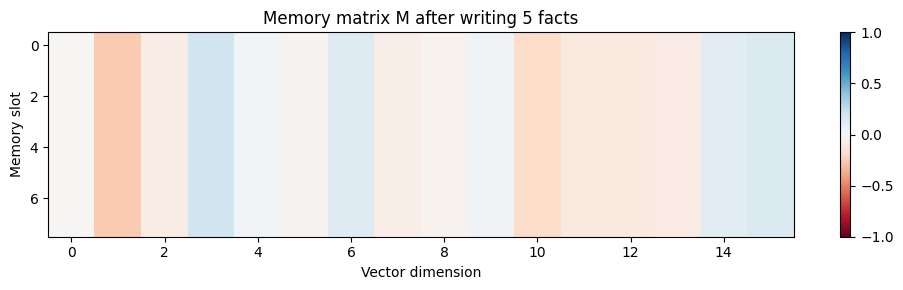

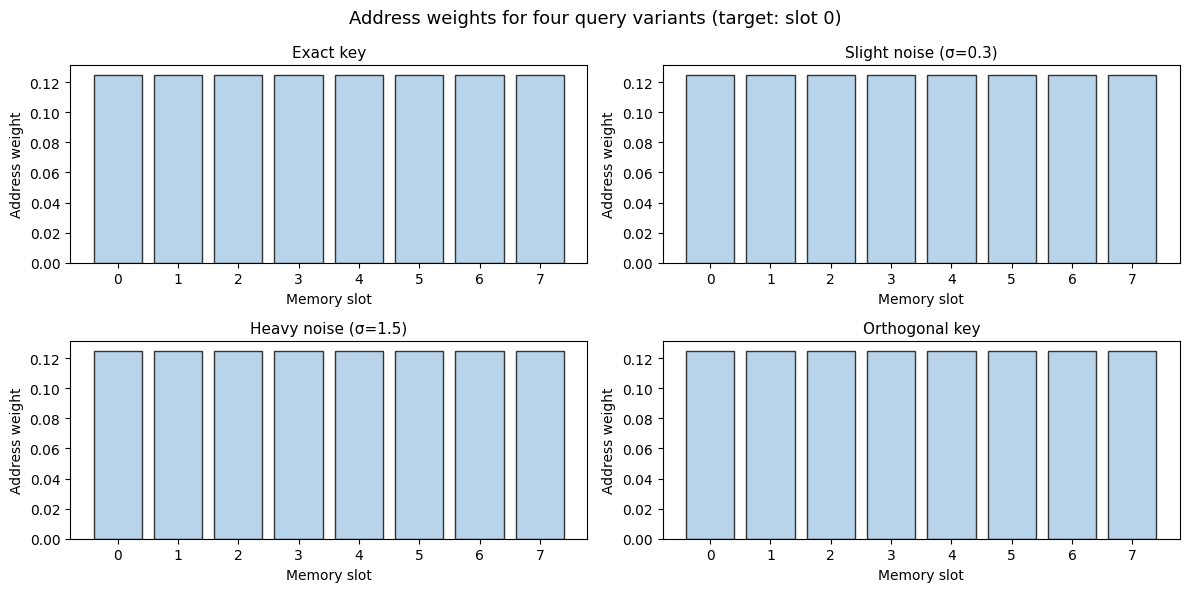

In [11]:
torch.manual_seed(0)

N_FACTS: int = 5

# --- generate 5 random unit-normalized key vectors and value vectors ---
raw_keys: torch.Tensor = torch.randn(N_FACTS, VEC_DIM)
fact_keys: torch.Tensor = F.normalize(raw_keys, dim=1)          # unit vectors
fact_values: torch.Tensor = torch.randn(N_FACTS, VEC_DIM) * 0.8

# erase vector: all ones = full overwrite (writing into fresh slots)
erase_vec: torch.Tensor = torch.ones(VEC_DIM)

# --- write each (key → value) pair into memory using the key as the address ---
mem: torch.Tensor = torch.zeros(N_SLOTS, VEC_DIM)
for i in range(N_FACTS):
    w: torch.Tensor = content_address(fact_keys[i], mem)
    mem = memory_write(mem, w, erase_vec, fact_values[i])

# --- visualize memory matrix after all writes ---
fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(mem.detach().numpy(), cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
ax.set_xlabel("Vector dimension")
ax.set_ylabel("Memory slot")
ax.set_title("Memory matrix M after writing 5 facts")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# --- define four query variants ---
query_exact: torch.Tensor = fact_keys[0]
query_slight: torch.Tensor = F.normalize(fact_keys[0] + 0.3 * torch.randn(VEC_DIM), dim=0)
query_heavy: torch.Tensor = F.normalize(fact_keys[0] + 1.5 * torch.randn(VEC_DIM), dim=0)

# orthogonal key: use a random vector orthogonalized to key[0]
rand_vec: torch.Tensor = torch.randn(VEC_DIM)
rand_vec = rand_vec - (rand_vec @ fact_keys[0]) * fact_keys[0]
query_orthogonal: torch.Tensor = F.normalize(rand_vec, dim=0)

queries: list[tuple[str, torch.Tensor]] = [
    ("Exact key", query_exact),
    ("Slight noise (\u03c3=0.3)", query_slight),
    ("Heavy noise (\u03c3=1.5)", query_heavy),
    ("Orthogonal key", query_orthogonal),
]

# --- plot address weight distributions for all four queries ---
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes_flat: list = axes.flatten().tolist()

for ax, (title, q) in zip(axes_flat, queries):
    w: torch.Tensor = content_address(q, mem)
    w_np: np.ndarray = w.detach().numpy()
    # normalize for colormap so highest bar is darkest blue
    normed: np.ndarray = (w_np - w_np.min()) / (w_np.max() - w_np.min() + 1e-9)
    bar_colors: np.ndarray = plt.cm.Blues(0.3 + 0.7 * normed)
    ax.bar(range(N_SLOTS), w_np, color=bar_colors, edgecolor="#333")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Memory slot")
    ax.set_ylabel("Address weight")
    ax.set_xticks(range(N_SLOTS))
    ax.set_ylim(0, None)

fig.suptitle("Address weights for four query variants (target: slot 0)", fontsize=13)
plt.tight_layout()
plt.show()

<details>
<summary>graceful degradation — why this matters</summary>

A hash table either returns the stored value exactly, or raises a KeyError. There is no in-between. The NTM's content-based addressing has no such cliff: as the query drifts away from the stored key, the address distribution broadens gradually. The system still returns *something* — a blend weighted by similarity to all stored patterns.

This is not a failure mode to be engineered away. It is the defining feature of associative memory. Human memory works the same way: a noisy or partial cue ('what was that song that goes...') still retrieves something plausible, often correct, sometimes a near-miss. The reconstruction is approximate but guided.

For agents operating in noisy environments — parsing imperfect tool outputs, handling ambiguous user instructions, reasoning over partially-observed state — graceful degradation under query noise is strictly more useful than exact-match-or-fail. The NTM's memory model is, in this specific sense, more robust than a dictionary.

</details>

# Section 3 — The Dictionary Contrast

Let's make the difference between NTM memory and a Python dictionary brutally clear.

In [12]:
# --- Python dictionary: exact lookup only ---
facts: dict[str, str] = {
    "capital of France": "Paris",
    "boiling point of water": "100\u00b0C",
}

# exact key works
print(f"Exact:  {facts['capital of France']}")

# noisy key fails
noisy_key: str = "capitel of Frence"
try:
    print(facts[noisy_key])
except KeyError as e:
    print(f"KeyError: {e}")

Exact:  Paris
KeyError: 'capitel of Frence'


In [13]:
# --- NTM lookup: use a noisy version of fact_keys[0] as the query ---
# (pretend fact_keys[0] encodes 'capital of France')
torch.manual_seed(99)
noisy_query: torch.Tensor = F.normalize(fact_keys[0] + 0.4 * torch.randn(VEC_DIM), dim=0)

# address and retrieve from the NTM memory populated in Section 2e
noisy_weights: torch.Tensor = content_address(noisy_query, mem)
retrieved_noisy: torch.Tensor = memory_read(noisy_weights, mem)

# measure correctness: cosine similarity to the stored value
correct_value: torch.Tensor = fact_values[0]
similarity: float = float(
    F.cosine_similarity(retrieved_noisy.unsqueeze(0),
                        correct_value.unsqueeze(0)).item()
)

print(f"NTM retrieved a vector of norm {retrieved_noisy.norm().item():.3f}")
print(f"Cosine similarity to correct value vector: {similarity:.3f}")
print("(1.0 = perfect recall, 0.0 = unrelated)")

NTM retrieved a vector of norm 0.483
Cosine similarity to correct value vector: 0.414
(1.0 = perfect recall, 0.0 = unrelated)


**Is that remembering? You decide.**

<details>
<summary>what 'reasonable retrieval' actually means</summary>

The NTM does not return the string "Paris". It returns a vector — the same kind of high-dimensional floating-point object that flows through every layer of a neural network. We cannot read this vector the way we read text. What we *can* do is measure its geometric relationship to the stored value vector using cosine similarity.

A similarity of 1.0 means the retrieved vector points in exactly the same direction as the stored value — perfect recall. A similarity of 0.0 means the two vectors are orthogonal — the retrieved vector shares nothing with the stored one. In practice, a noisy query returns a retrieval that sits somewhere between these extremes: recognizably related to the correct answer, degraded by the noise in the cue.

This is why the latent representation matters. If memory stored tokens, we would need to decode the retrieved vector back into words to evaluate it — a lossy and ambiguous step. Because both the stored value and the retrieved vector live in the same continuous space, we can evaluate recall quantitatively, without ever leaving the representational substrate of the network.

</details>

# Section 4 — Memorizing Transformers: The KV Twist

Memorizing Transformers don't invent a new memory format. They reuse the exact same mechanism the transformer already uses for attention — but point it at a bank of past context.

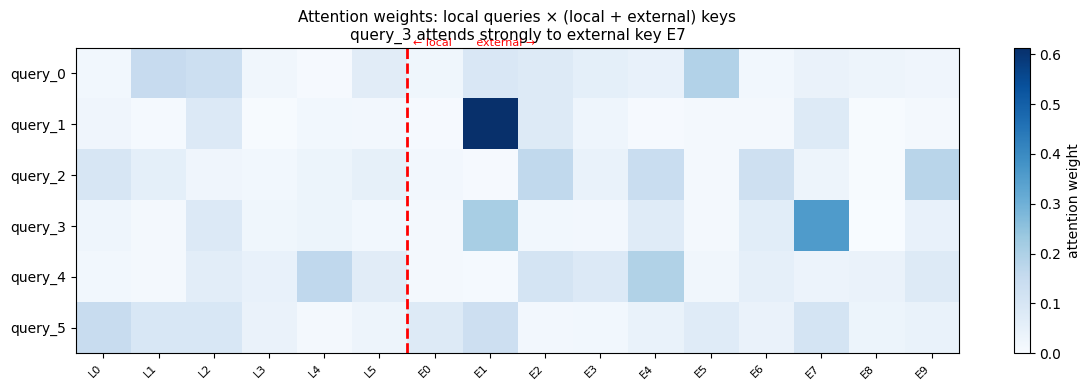

query_3 top attention → column 13 = 'E7' (weight=0.357)


In [14]:
torch.manual_seed(5)

D_MODEL: int = 16
N_LOCAL: int = 6      # tokens in the local window
N_EXT: int = 10       # past (K, V) pairs in external memory bank

# --- local context: Q, K, V for current window ---
local_Q: torch.Tensor = torch.randn(N_LOCAL, D_MODEL)
local_K: torch.Tensor = torch.randn(N_LOCAL, D_MODEL)
local_V: torch.Tensor = torch.randn(N_LOCAL, D_MODEL)

# --- external memory bank: 10 past key-value pairs ---
ext_K: torch.Tensor = torch.randn(N_EXT, D_MODEL)
ext_V: torch.Tensor = torch.randn(N_EXT, D_MODEL)

# --- plant a strong match: local query 3 should retrieve external key 7 ---
ext_K[7] = F.normalize(local_Q[3] + 0.05 * torch.randn(D_MODEL), dim=0) * 3.0

# --- concatenate local and external keys/values ---
K_full: torch.Tensor = torch.cat([local_K, ext_K], dim=0)   # (N_LOCAL + N_EXT, D_MODEL)
V_full: torch.Tensor = torch.cat([local_V, ext_V], dim=0)

# --- compute attention scores for all queries against the full key set ---
attn_scores: torch.Tensor = local_Q @ K_full.T / (D_MODEL ** 0.5)
attn_weights: torch.Tensor = F.softmax(attn_scores, dim=-1)  # (N_LOCAL, N_LOCAL + N_EXT)

# --- visualize: rows = local queries, columns = local + external keys ---
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(
    attn_weights.detach().numpy(), cmap="Blues",
    aspect="auto", vmin=0, vmax=attn_weights.max().item()
)

# column labels
col_labels: list[str] = (
    [f"L{i}" for i in range(N_LOCAL)] +
    [f"E{i}" for i in range(N_EXT)]
)
ax.set_xticks(range(N_LOCAL + N_EXT))
ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(N_LOCAL))
ax.set_yticklabels([f"query_{i}" for i in range(N_LOCAL)])

# vertical dashed separator between local and external
ax.axvline(x=N_LOCAL - 0.5, color="red", linewidth=2, linestyle="--", label="local | external")
ax.text(N_LOCAL - 0.5 + 0.1, -0.7, "← local       external →",
        color="red", fontsize=8, va="top")

ax.set_title(
    "Attention weights: local queries × (local + external) keys\n"
    "query_3 attends strongly to external key E7",
    fontsize=11
)
plt.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout()
plt.show()

# confirm query 3's strongest key
top_col: int = int(attn_weights[3].argmax().item())
print(f"query_3 top attention → column {top_col} = '{col_labels[top_col]}' "
      f"(weight={attn_weights[3, top_col]:.3f})")

<details>
<summary>why the same vocabulary matters</summary>

In NTM, memory access is a separate mechanism bolted onto the model — a controller with dedicated read and write heads that use a different addressing scheme than the main attention layers. It works, but there is a seam: the model has two representational worlds and must translate between them.

Memorizing Transformers (Wu et al., 2022) remove the seam. The external memory bank stores (K, V) pairs in exactly the same format as the local context. The retrieval operation is exactly the same scaled dot-product attention the model uses for everything else. There is no mode switch, no separate read head, no translation step.

This means that when you extend a standard transformer with a Memorizing Transformer memory bank, you are not adding a new capability — you are extending an existing one. The model's internal language (the geometry of its key and query spaces) does not change. Past context and current context are both keys and values; the model cannot tell — and does not need to know — which side of the separator line a particular key came from.

</details>

The boundary between local context and retrieved memory is architectural, not representational. The model does not know — or care — which side of the line a key came from.

# Section 5 — Beyond: Titans, Mamba, and the Spectrum

## 5a — Titans: Learning While Thinking

Titans (Behrouz et al., 2024, Google Research) takes this one step further. Instead of *addressing* a fixed external memory, the long-term memory module in Titans is itself a small neural network — and its weights are updated via gradient descent *during the forward pass*.

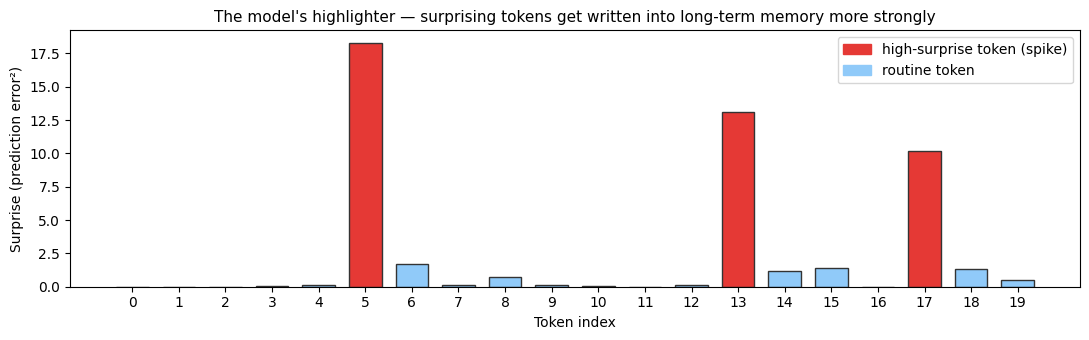

In [16]:
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(12)

SEQ_LEN: int = 20

# --- synthetic token sequence with a few high-surprise spikes ---
token_values: torch.Tensor = torch.randn(SEQ_LEN) * 0.3
# inject unexpected spikes at positions 5, 13, 17
spike_positions: list[int] = [5, 13, 17]
for pos in spike_positions:
    token_values[pos] = 3.5 + torch.rand(1).item()

# --- compute surprise as prediction error vs. running mean ---
running_mean: float = 0.0
surprise: list[float] = []
alpha: float = 0.3   # exponential moving average coefficient

for t in range(SEQ_LEN):
    val: float = token_values[t].item()
    err: float = (val - running_mean) ** 2    # squared prediction error
    surprise.append(err)
    running_mean = alpha * val + (1 - alpha) * running_mean

surprise_arr: np.ndarray = np.array(surprise)

# --- plot surprise signal, highlight spike positions in red ---
colors: list[str] = [
    "#e53935" if i in spike_positions else "#90caf9"
    for i in range(SEQ_LEN)
]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(range(SEQ_LEN), surprise_arr, color=colors, edgecolor="#333", width=0.7)
ax.set_xlabel("Token index")
ax.set_ylabel("Surprise (prediction error²)")
ax.set_title(
    "The model's highlighter — surprising tokens get written into long-term memory more strongly",
    fontsize=11
)
ax.set_xticks(range(SEQ_LEN))

# legend patches
import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color="#e53935", label="high-surprise token (spike)"),
    mpatches.Patch(color="#90caf9", label="routine token")
], loc="upper right")

plt.tight_layout()
plt.show()

<details>
<summary>learning during inference — what it means</summary>

In every transformer you have ever used, inference is inference and training is training. The weights are frozen once training is done. The model's 'knowledge' is fixed; the forward pass is just matrix multiplication.

Titans breaks this boundary. The long-term memory module is a small MLP whose weights are updated via gradient descent *during the forward pass*, using the surprise signal as a learning rate modulator. A high-surprise token causes a larger weight update; a routine token causes a smaller one. The memory module is literally learning from the sequence it is currently processing.

This has a radical implication: the model is no longer stateless at inference time. Processing a document changes the memory module's weights. Those weights are the model's accumulated experience of this particular document. The boundary between 'what I was trained on' and 'what I am thinking about right now' becomes blurry — which is arguably closer to how biological cognition works than any previous architecture.

</details>

## 5b — Mamba / SSMs: Compression Without Addressability

Mamba (Gu & Dao, 2023) takes a fundamentally different approach. Instead of an external addressable memory, all history is compressed into a fixed-size hidden state vector that evolves recurrently.

The tradeoff is stark:
- **NTM / Memorizing Transformers**: you can look up a specific past event. Cost: O(N) or O(N²) in memory/compute.
- **Mamba**: linear time, constant memory. But you cannot look up — you can only compress.

Think of NTM as a filing cabinet you can search. Mamba is a single notebook page that gets continuously rewritten — efficient, but lossy.

## 5c — The Spectrum

Placing all mechanisms on two axes: expressiveness (can it store and retrieve specific past events?) vs. computational cost.

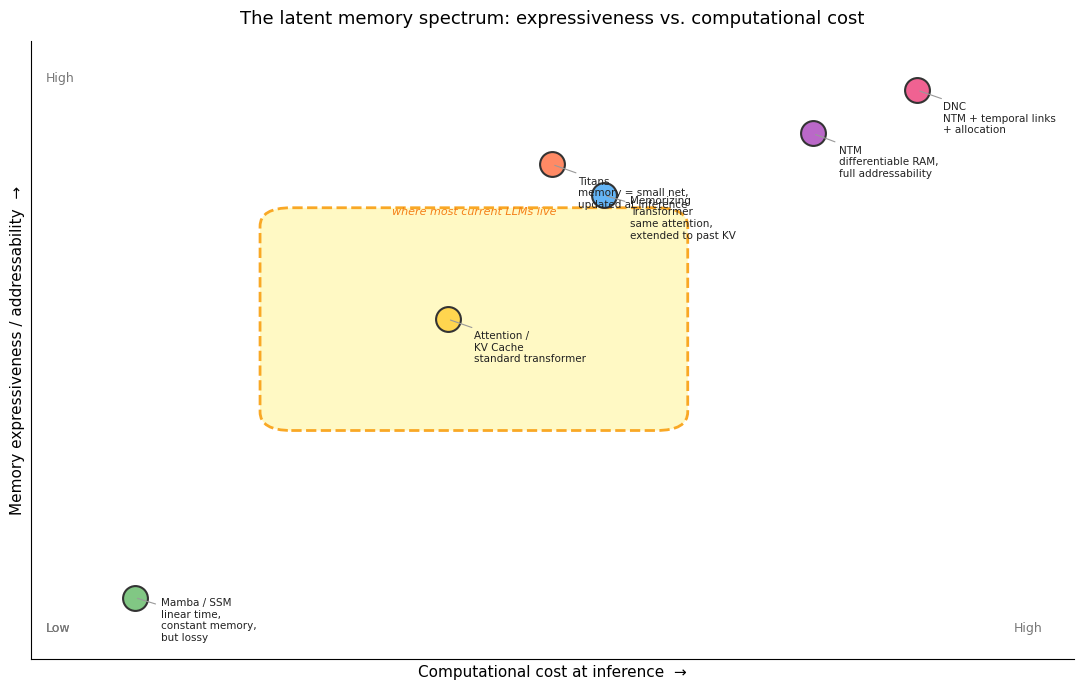

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- mechanism data: (name, description, x=compute_cost, y=addressability, color) ---
mechanisms: list[tuple[str, str, float, float, str]] = [
    ("Mamba / SSM",
     "linear time,\nconstant memory,\nbut lossy",
     1.0, 1.0, "#81c784"),
    ("Memorizing\nTransformer",
     "same attention,\nextended to past KV",
     5.5, 7.5, "#64b5f6"),
    ("Titans",
     "memory = small net,\nupdated at inference",
     5.0, 8.0, "#ff8a65"),
    ("NTM",
     "differentiable RAM,\nfull addressability",
     7.5, 8.5, "#ba68c8"),
    ("DNC",
     "NTM + temporal links\n+ allocation",
     8.5, 9.2, "#f06292"),
    ("Attention /\nKV Cache",
     "standard transformer",
     4.0, 5.5, "#ffd54f"),
]

fig, ax = plt.subplots(figsize=(11, 7))

# --- shaded region for 'where most current LLMs live' ---
llm_patch = mpatches.FancyBboxPatch(
    (2.5, 4.0), 3.5, 3.0,
    boxstyle="round,pad=0.3",
    facecolor="#fff9c4", edgecolor="#f9a825",
    linewidth=2, linestyle="--", zorder=1
)
ax.add_patch(llm_patch)
ax.text(4.25, 7.15, "where most current LLMs live",
        ha="center", va="bottom", fontsize=8, color="#f57f17", style="italic")

# --- plot each mechanism ---
for (name, desc, x, y, color) in mechanisms:
    ax.scatter(x, y, s=320, color=color, edgecolors="#333",
               linewidths=1.5, zorder=5)
    ax.annotate(
        f"{name}\n{desc}",
        xy=(x, y), xytext=(x + 0.25, y - 0.7),
        fontsize=7.5, color="#222",
        arrowprops=dict(arrowstyle="-", color="#999", lw=0.8),
        zorder=6
    )

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel("Computational cost at inference  →", fontsize=11)
ax.set_ylabel("Memory expressiveness / addressability  →", fontsize=11)
ax.set_title(
    "The latent memory spectrum: expressiveness vs. computational cost",
    fontsize=13, pad=12
)
ax.set_xticks([])
ax.set_yticks([])
ax.text(0.15, 0.5, "Low", fontsize=9, color="#777", va="center")
ax.text(9.7, 0.5, "High", fontsize=9, color="#777", va="center", ha="right")
ax.text(0.15, 0.5, "Low", fontsize=9, color="#777", va="center")
ax.text(0.15, 9.5, "High", fontsize=9, color="#777", va="top")

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

<details>
<summary>where research is going</summary>

The spectrum is not a ranking where higher-right is always better. Different points are optimal for different tasks. Long-document question answering needs addressable memory; real-time streaming classification needs constant-memory efficiency.

The current frontier is *hybrid architectures* that combine multiple mechanisms in the same model. Jamba (AI21 Labs, 2024) interleaves Mamba SSM layers with standard attention layers, capturing the efficiency of recurrent compression for long-range dependencies while preserving the precision of attention for local context. The intuition: let SSM handle the 'gist' of distant history, and attention handle the details of the current window.

Titans takes a different hybrid approach: a fast attention window + a slow memory module that learns from the sequence. The 'fast' and 'slow' framing echoes the dual-process theories of cognition (Kahneman's System 1 / System 2) — though the analogy should not be pushed too far.

The unifying question for the next few years: can we get addressable retrieval at linear cost? Current evidence suggests no, but the gap is narrowing. Every point on the spectrum is a live research program.

</details>